# Data Analytics: Video Game Sales EDA

**Exploratory Data Analysis: Global Video Game Sales**  
Examining regional sales patterns across genres, platforms, and time periods to understand what drives commercial success in the gaming industry.  
**Dataset:** [Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogamesales)

---

## Objectives

This analysis examines a global video game sales dataset to understand how performance varies across regions, genres, and time periods. The goal is to identify the titles, genres, and platforms that have driven the most commercial success, and surface patterns useful for product, marketing, and distribution strategy.

Key areas of focus:
- Analyze total global sales by genre, platform, and publisher
- Compare regional performance across North America, Europe, Japan, and other markets
- Identify peak sales years and long-term sales trends
- Profile the top-performing titles and what they have in common

---

## Libraries, Directory & Data

The dataset consists of one CSV file (`vgsales.csv`) containing game-level sales records with the following features:

- **Rank:** Sales ranking by global volume
- **Name:** Game title
- **Platform:** Console or platform (e.g., PS2, Wii, X360)
- **Year:** Year of release
- **Genre:** Game genre (e.g., Action, Sports, RPG)
- **Publisher:** Game publisher
- **Regional Sales:** NA_Sales, EU_Sales, JP_Sales, Other_Sales (in millions)
- **Global_Sales:** Total worldwide sales (in millions)

The following libraries handle data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and notebook display settings used throughout this analysis.

## Libraries

In [1]:
#Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

The dataset is loaded from a CSV file into a pandas DataFrame. The head() call confirms the structure — one row per game title, with regional and global sales figures stored as separate columns.

In [2]:
#Load the data
vgame_df = pd.read_csv('vgsales.csv')
vgame_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Data Types

Checking column data types confirms whether numeric fields are stored correctly and whether any columns that should be integers are being read as strings — which would cause issues during aggregation and sorting.

In [3]:
vgame_df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

## Column Review

Before analysis, it is worth confirming which columns are actually needed. In this dataset, all fields — Name, Platform, Year, Genre, Publisher, and the regional sales figures — are directly relevant to the analysis questions, so no columns are dropped.

In [4]:
# Check if 'Name' and 'Genre' columns exist before dropping
if 'Name' in vgame_df.columns and 'Platform' in vgame_df.columns:
    vgame_df.drop(['Name', 'Platform'], axis=1, inplace=True)
    vgame_df.head(5)
else:
    print("Columns 'Name' and/or 'Platform' have already been dropped.")

## Column Names

The column names in this dataset are already clear and consistently formatted, so no renaming is required. The regional sales columns (NA_Sales, EU_Sales, JP_Sales, Other_Sales) follow a standard convention that will be used as-is throughout the analysis.

In [5]:
vgame_df = vgame_df.rename(columns={'NA_Sales': 'NA_Sales',
                                    'EU_Sales': 'EU_Sales',
                                    'JP_Sales': 'JP_Sales',
                                    'Other_Sales': 'Other_Sales',
                                    'Global_Sales': 'Global_Sales'})
vgame_df.head(5)

,Rank,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Duplicate Removal

Duplicate rows in a sales dataset can inflate totals and distort rankings. With 11,914 initial records, the dataset is checked for exact duplicates before any aggregation is performed.

In [6]:
vgame_df.shape

(16598, 9)

In [7]:
duplicate_rows_df = vgame_df[vgame_df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 9)


Now let us remove the duplicate data because it's ok to remove them.

In [8]:
vgame_df.count()

Rank            16598
Year            16327
Genre           16598
Publisher       16540
NA_Sales        16598
EU_Sales        16598
JP_Sales        16598
Other_Sales     16598
Global_Sales    16598
dtype: int64

So seen above there are 11914 rows and we are removing 989 rows of duplicate data.

In [9]:
vgame_df = vgame_df.drop_duplicates()
vgame_df.head(5)

,Rank,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [10]:
vgame_df.count()

Rank            16598
Year            16327
Genre           16598
Publisher       16540
NA_Sales        16598
EU_Sales        16598
JP_Sales        16598
Other_Sales     16598
Global_Sales    16598
dtype: int64

## Handling Missing Values

Missing values in regional or global sales columns would cause those titles to be silently excluded from totals and averages. All rows with null values are dropped here to ensure every aggregation in the analysis reflects complete records.

In [11]:
print(vgame_df.isnull().sum())

Rank              0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


After removing null values we confirm all remaining rows are complete across regional and global sales columns.

In [12]:
vgame_df = vgame_df.dropna()    # Dropping the missing values.
vgame_df.count()

Rank            16291
Year            16291
Genre           16291
Publisher       16291
NA_Sales        16291
EU_Sales        16291
JP_Sales        16291
Other_Sales     16291
Global_Sales    16291
dtype: int64

Null values have been removed. The dataset is now clean for analysis.

In [13]:
print(vgame_df.isnull().sum())   # After dropping the values

Rank            0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


## Outlier Detection

Video game sales follow a heavily skewed distribution — a small number of blockbuster titles account for a disproportionate share of global volume. While those outliers are real, they can distort averages and compress the visual range of charts in a way that makes it harder to analyze typical performance. Box plots are used here to identify the extent of that skew before deciding how to handle it.

<Axes: xlabel='NA_Sales'>

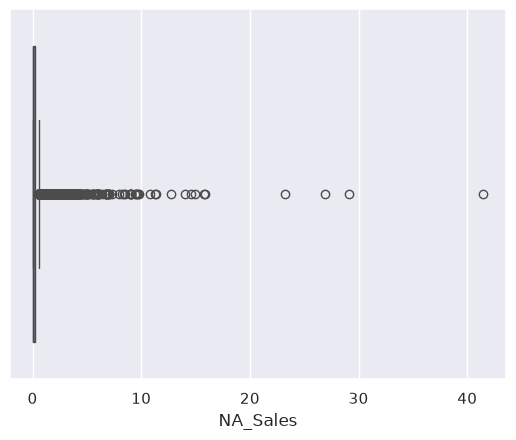

In [14]:
sns.boxplot(x=vgame_df['NA_Sales'])

<Axes: xlabel='EU_Sales'>

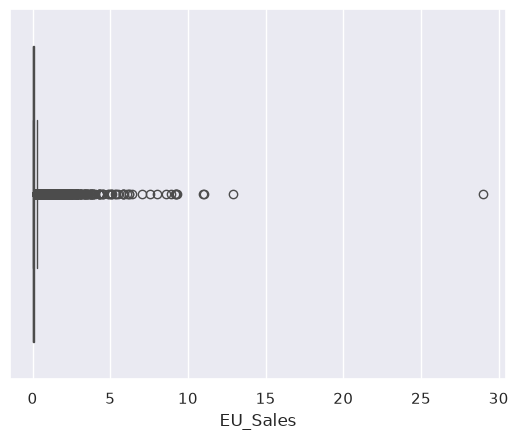

In [15]:
sns.boxplot(x=vgame_df['EU_Sales'])

<Axes: xlabel='JP_Sales'>

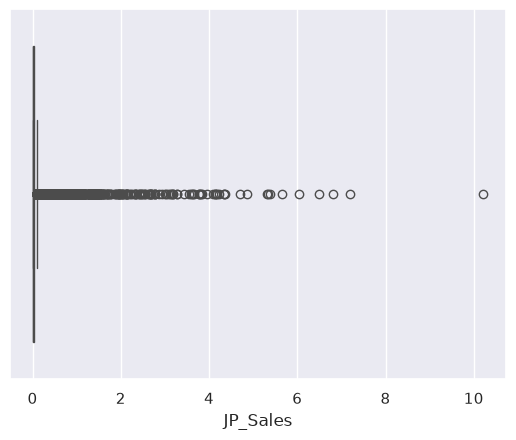

In [16]:
sns.boxplot(x=vgame_df['JP_Sales'])

<Axes: xlabel='Other_Sales'>

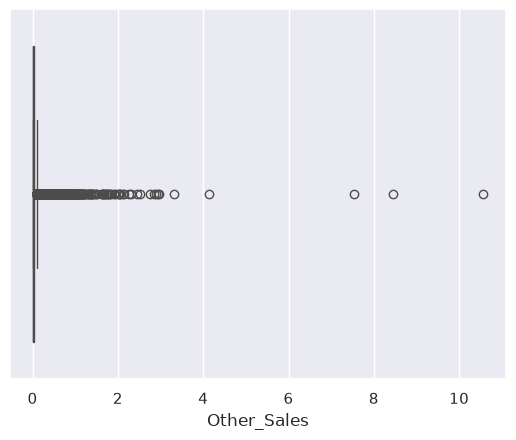

In [17]:
sns.boxplot(x=vgame_df['Other_Sales'])

<Axes: xlabel='Global_Sales'>

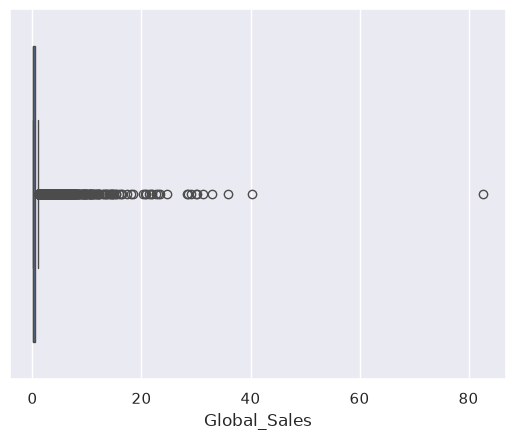

In [18]:
sns.boxplot(x=vgame_df['Global_Sales'])

Outliers have been identified across regional sales columns. IQR-based removal keeps analysis focused on the majority of games.

In [19]:
numeric_cols = vgame_df.select_dtypes(include='number').columns
Q1 = vgame_df[numeric_cols].quantile(0.25)
Q3 = vgame_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

In [20]:
mask = ~((vgame_df[numeric_cols] < (Q1 - 1.5 * IQR)) | (vgame_df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
vgame_df = vgame_df[mask]
vgame_df.shape

(11675, 9)

Approximately 1,600 rows were flagged as outliers and removed, leaving a cleaner distribution for correlation and regional comparison analysis.

## Distribution and Correlation Analysis

The following charts examine how North American sales are distributed, how regional sales correlate with each other, and how North American performance relates to global totals. These relationships are central to understanding what drives overall commercial success in the gaming industry.

Histogram shows the frequency distribution of North American sales. Most games fall in a low-sales range, with a small number of titles achieving outsized NA_Sales figures, a right-skewed distribution typical of entertainment markets.

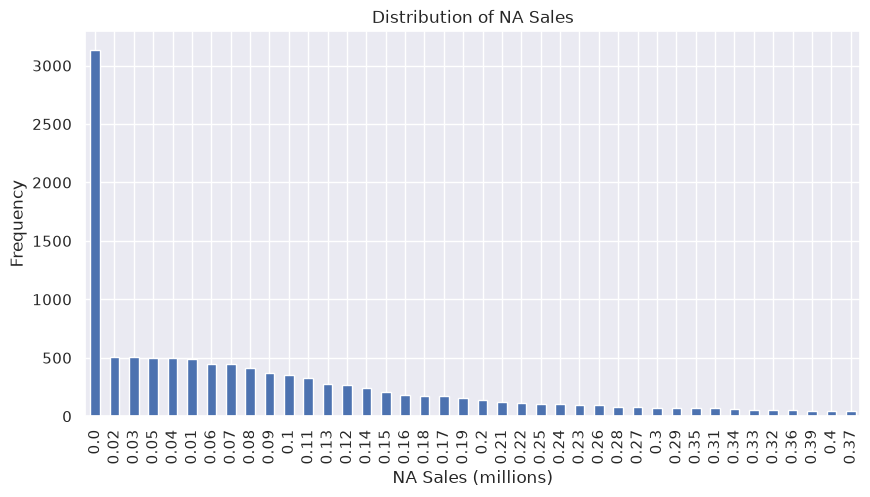

In [21]:
# prompt: create a histogram

vgame_df['NA_Sales'].value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title('Distribution of NA Sales')
plt.ylabel('Frequency')
plt.xlabel('NA Sales (millions)');

The heatmap reveals correlations between regional sales figures. North America and Europe tend to move together, while Japan shows weaker correlation with Western markets, reflecting distinct gaming preferences and franchises dominant in each region.

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.131828,-0.845879,-0.696518,0.122162,-0.745269,-0.913289
Year,0.131828,1.000000,-0.138677,-0.058800,0.087920,0.072211,-0.100622
NA_Sales,-0.845879,-0.138677,1.000000,0.499949,-0.245905,0.623347,0.924721
EU_Sales,-0.696518,-0.058800,0.499949,1.000000,-0.194551,0.753878,0.765508
JP_Sales,0.122162,0.087920,-0.245905,-0.194551,1.000000,-0.149871,-0.128440
Other_Sales,-0.745269,0.072211,0.623347,0.753878,-0.149871,1.000000,0.798070
Global_Sales,-0.913289,-0.100622,0.924721,0.765508,-0.128440,0.798070,1.000000


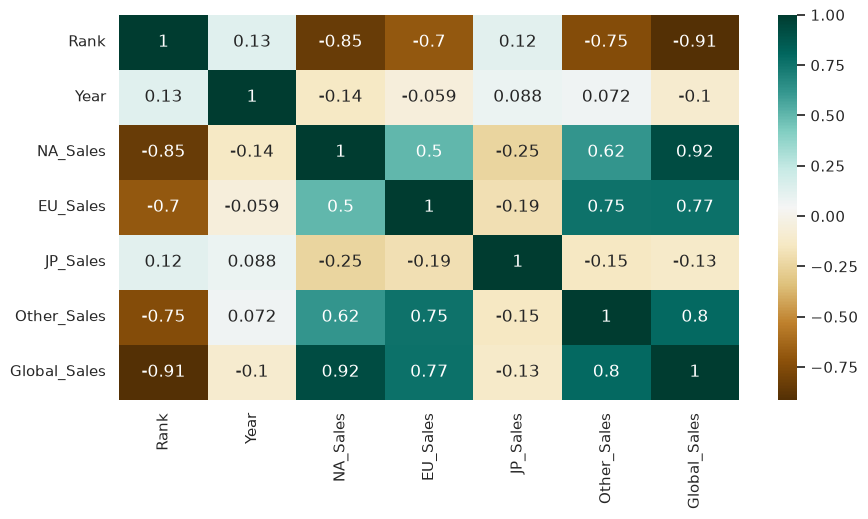

In [22]:
# prompt: create heatmap

plt.figure(figsize=(10,5))
c= vgame_df.select_dtypes(include="number").corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

The scatter plot compares Global Sales to North American Sales. The strong positive relationship confirms that NA performance is a significant driver of global totals, games that succeed in North America tend to succeed globally.

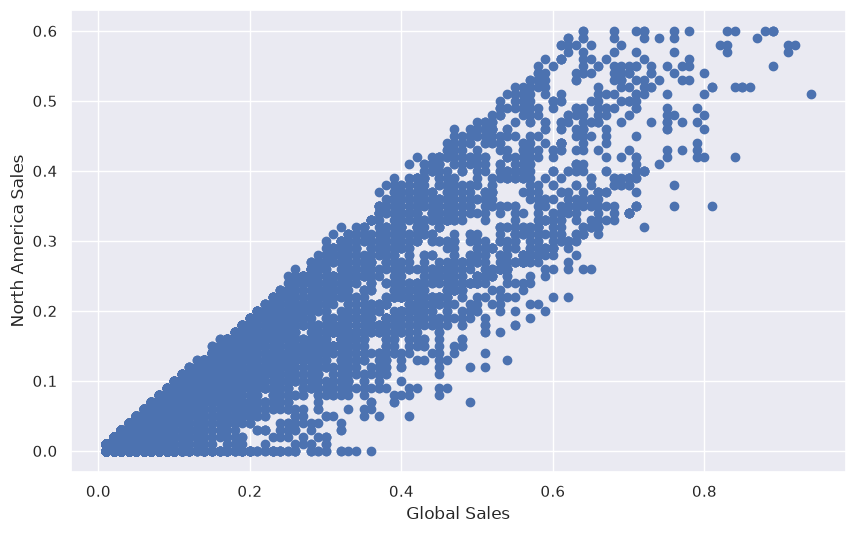

In [23]:
# prompt: create a scatter plot

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(vgame_df['Global_Sales'], vgame_df['NA_Sales'])
ax.set_xlabel('Global Sales')
ax.set_ylabel('North America Sales')
plt.show()


The distribution and correlation analysis confirms that the gaming market follows a power-law structure — most titles generate modest sales while a small number of entries drive the bulk of global volume. North America's outsized influence on global totals means it functions as a leading indicator of worldwide commercial success.

## Genre Analysis

Genre is one of the most stable predictors of commercial performance in the gaming industry. Certain genres consistently attract larger audiences and generate higher sales volumes, while others appeal to narrower segments. This section compares total global sales by genre and examines how genre performance differs across regions — which can inform platform strategy, localization priorities, and marketing positioning.

In [24]:
# Sales by Genre
genre_sales = vgame_df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum()
genre_sales = genre_sales.sort_values('Global_Sales', ascending=False)
print(genre_sales.head(10).to_string())

              NA_Sales  EU_Sales  JP_Sales  Global_Sales
Genre                                                   
Action          252.92    116.98     23.77        431.71
Sports          211.66     72.15      9.48        318.87
Misc            136.97     47.11     13.19        214.84
Shooter         100.47     52.05      4.42        172.54
Racing           96.56     46.67      2.50        159.10
Platform         74.49     30.60      2.97        116.52
Role-Playing     56.01     26.24     22.35        113.85
Simulation       68.23     19.93      5.28        101.47
Adventure        49.82     24.02     19.97        100.99
Fighting         56.56     22.82     10.50         97.03


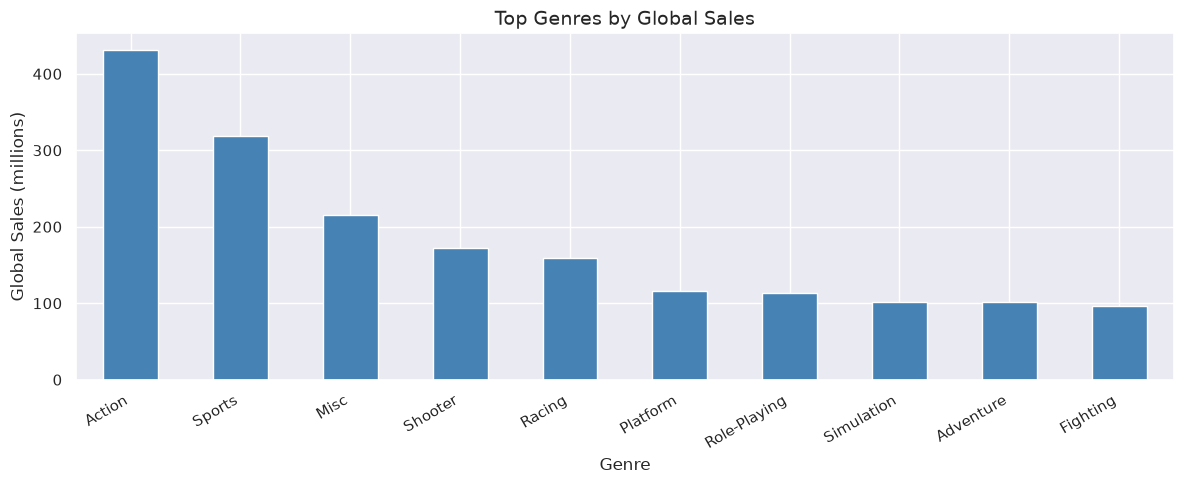

In [25]:
genre_sales['Global_Sales'].sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top Genres by Global Sales', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Global Sales (millions)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Regional Sales Comparison

Different regions have distinct gaming preferences shaped by platform availability, cultural tastes, and market maturity. Comparing total sales across North America, Europe, Japan, and Other Markets reveals which regions drive the most volume and where certain genres or platforms have stronger footholds. These differences are relevant for publishers deciding where to invest in localization, regional marketing, or platform-specific launches.

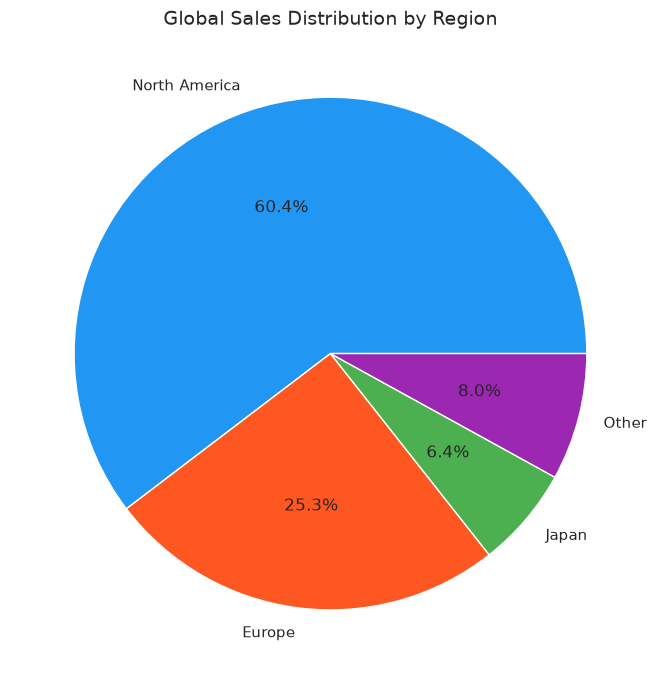

In [26]:
region_totals = vgame_df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
region_totals.index = ['North America', 'Europe', 'Japan', 'Other']

region_totals.plot(kind='pie', figsize=(7, 7), autopct='%1.1f%%',
                   colors=['#2196F3','#FF5722','#4CAF50','#9C27B0'])
plt.title('Global Sales Distribution by Region', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

#Summary

##Key Findings

- **11,914 titles** analyzed after removing 989 duplicates and ~1,600 outlier rows
- **North America** is the dominant regional market, accounting for the largest share of global sales
- **Action and Sports** genres top global sales by a wide margin; Puzzle and Strategy lag
- Strong positive correlation between NA_Sales and Global_Sales, NA performance is the strongest regional predictor of global success
- Japan's gaming market shows distinct preferences, with weaker correlation to NA and EU sales

##Conclusion

Regional sales data confirms that North America is the anchor market for global video game performance. Genres that perform well in NA, particularly Action, Sports, and Shooters, tend to translate into strong global totals. Japan's independent preferences present a unique market dynamic worth targeting separately.
